Давайте подивимося, як LSTM можна використовувати для побудови нейронної мережі прогнозування часових.

Будемо працювати з задачею прогнозування кількості пасажирів міжнародних авіаліній. З цим набором даних ми вже працювали в лекції "Time Series Analysis" і ви зможете порівняти результати :)

Задача полягає в тому, щоб за заданими роком і місяцем передбачити кількість пасажирів міжнародних авіаліній в одиницях виміру 1,000. Дані охоплюють період з січня 1949 року по грудень 1960 року, тобто 12 років, зі 144 спостереженнями.

Це регресійна задача. Тобто, знаючи кількість пасажирів (в тисячах) за останні місяці, можна передбачити, якою буде кількість пасажирів у наступному місяці. Набір даних має лише одну характеристику: "Кількість пасажирів" - `Passengers`.

Далі вже наведений код для читання даних, але нам їх ще треба буде трошки обробити.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader

In [22]:
# load data
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.set_index('Month', inplace=True)
display(df.head())

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


**Завдання 1.** Створіть змінну типу `numpy.ndarray`, яка містить значення кількості пасажирів в форматі `float32`. Такий формат даних нам треба для тренування нейромережі.

In [23]:
num_pessengers = df['Passengers'].values.astype(np.float32)
num_pessengers[:5]

array([112., 118., 132., 129., 121.], dtype=float32)

Очікуваний результат:
```array([112., 118., 132., 129., 121.], dtype=float32)```

**Завдання 2**. Розбийте дані на тренувальні і валідаційні у співвідношенні 67% йде у тренування, 33 - у валідацію. Памʼятаємо, що ми працюємо з tim series, відповідно, навчаємось на давніших, валідуємось - на новіших.

In [24]:
n = len(num_pessengers)
print(f"num_pessengers size: {n}")

split_index = int(n * 0.67)
train, test = num_pessengers[:split_index], num_pessengers[split_index:]

print(f"train size: {len(train)}")
print(f"validation size: {len(test)}")

num_pessengers size: 144
train size: 96
validation size: 48


In [25]:
print("First 5 train elements:", train[:5])
print("First 5 test elements: ", test[:5])

First 5 train elements: [112. 118. 132. 129. 121.]
First 5 test elements:  [315. 301. 356. 348. 355.]


In [26]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train.reshape(-1, 1)).astype(np.float32).flatten()
test_scaled = scaler.transform(test.reshape(-1, 1)).astype(np.float32).flatten()

**Завдання 3**.

Реалізуйте функцію `create_dataset`, яка перетворить одномірний часовий ряд (набір даних) у формат, придатний для тренування нейромережі.

Функція повинна приймати два аргументи:
- `dataset` — numpy-масив часового ряду,
- `lookback` — кількість попередніх кроків, які використовуватимуться для передбачення.

Функція повинна повернути два **тензори** PyTorch:
- `X` — набір ознак (вікно попередніх значень),
- `y` — цільові значення (наступні після вікна кроки).

Дані ми будемо подавати моделі в наступному форматі:
`
tensor([[112.],
        [118.],
        [132.],
        [129.],
        [121.]])
`
Відповідно першою розмірністю буде йти розмір вхідного батча, а другою - розмір вхіднизх даних і в нас це 1, бо лише одне значення на вході щоразу.

Після виконання завдання запустіть код нижче. Ми будемо передбачати на основі кількості пасажирів в попередній день кількість пасажирів в наступний, тому `lookback == 1`.

In [27]:
def create_dataset(dataset: np.ndarray, lookback: int):
    X, y = [], []

    for i in range(len(dataset) - lookback):
        X.append(dataset[i: i + lookback])
        y.append(dataset[i+1: i+1+lookback])

    X = torch.tensor(np.array(X))
    y = torch.tensor(np.array(y))

    return X, y

In [28]:
lookback = 1
X_train, y_train = create_dataset(train_scaled, lookback=lookback)
X_test, y_test = create_dataset(test_scaled, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])


Очікуваний результат:
```
torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])
```

**Завдання 4**.

Зверніть увагу на розмірності в попередньому завданні. Ми
З допомогою модуля `torch.nn` опишіть клас `AirModel`, який є нейронною мережею для прогнозування кількості пасажирів за допомогою LSTM.

1. **Конструктор класу** повинен приймати параметри `hidden_size`, `num_layers` та ініціювати шари:
   - LSTM-шар з наступними параметрами:
     - `input_size` — кожна точка часового ряду є окремим входом,,
     - `hidden_size` — заданий в конструкторі класу мережі,
     - `num_layers=1` — кількість шарів LSTM, задана в конструкторі мережі,
     - `batch_first=True` — визначає, що першим виміром є розмір батчу.
   - Лінійний шар (`nn.Linear`) для перетворення виходу LSTM на прогноз однієї точки.

2. **Метод forward** повинен виконувати наступні дії:
   - Передати вхідний тензор через LSTM-шар і отримати виходи (ігноруючи приховані стани).
   - Пропустити вихід LSTM через лінійний шар для отримання остаточного прогнозу.

Створіть об'єкт класу `AirModel` зі значеннями параметрів `hidden_size=50`, `num_layers=1` і протестуйте роботу моделі на вхідному тензорі `tensor([[112.]])`. На цьому етапі ми маємо переконатись, що модель здатна генерувати передбачення з рандомно ініційованими вагами.

In [29]:
class AirModel(nn.Module):
    def __init__(self, hidden_size, num_layers):
        super(AirModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=lookback,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, out_features=1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out)
        return out

In [30]:
hidden_size = 50
num_layers = 1

model = AirModel(hidden_size, num_layers)
model

AirModel(
  (lstm): LSTM(1, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

In [31]:
model(torch.tensor([[112.]]))

tensor([[0.1379]], grad_fn=<AddmmBackward0>)

**Завдання 5**.

Створіть об'єкт DataLoader для завантаження даних, використовуючи тренувальні вибірки `X_train` та `y_train`. Ваш DataLoader повинен виконувати наступні вимоги:

1. Використовувати клас `TensorDataset`, щоб об'єднати тензори ознак `X_train` і цільових значень `y_train`.
2. Дані повинні завантажуватися невеликими батчами розміром 8 за допомогою параметра `batch_size`.
3. Використовувати параметр `shuffle=True`, щоб дані перемішувалися перед кожною епохою тренування.


In [32]:
batch_size = 8
train_ds = TensorDataset(X_train, y_train)
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

**Завдання 6**.

1. Реалізуйте навчання нейронної мережі `AirModel` для прогнозування часових рядів, використовуючи Adam-оптимізатор та функцію втрат MSE (середньоквадратичну похибку).
2. Створіть цикл тренування для 2000 епох, у якому на кожній епосі:
   - Виконуйте крок тренування моделі (прямий прохід, обчислення похибки, зворотний прохід і оновлення ваг).
   - Підраховуйте середню похибку на кожному батчі даних і зберігайте її у списку `losses`.
3. Раз на 100 епох проводьте валідацію моделі:
   - Перевіряйте модель на тренувальних та тестових даних без оновлення ваг.
   - Обчислюйте корінь середньоквадратичної похибки (RMSE) для тренувальної та тестової вибірок і виводьте результати на екран.
   
**Примітка:**
- Використовуйте вже створений `DataLoader` для отримання батчів даних.
- Валідацію виконуйте в режимі `eval()`, вимикаючи обчислення градієнтів з `torch.no_grad()`.

**Приклад виходу:**
```
Epoch 0: train RMSE 12.3456, test RMSE 15.6789
Epoch 100: train RMSE 9.8765, test RMSE 12.3456
...
```

In [33]:
n_epochs = 2000
validate_every = 100
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = F.mse_loss

In [34]:
def train_eval(num_epochs, model, dataloader, loss_fn, optimizer):
    all_losses = []
    for epoch in range(num_epochs + 1):
        epoch_loss = 0
        model.train()

        for X, y in dataloader:
            optimizer.zero_grad()

            # Compute the prediction error
            pred = model(X)
            loss = loss_fn(pred, y)

            # Backpropagation
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        # Calculate loss
        avg_loss = epoch_loss / len(dataloader)
        all_losses.append(avg_loss)

        if (epoch) % validate_every == 0:
            model.eval()

            with torch.no_grad():
                train_pred = model(X_train)
                train_rmse = torch.sqrt(loss_fn(train_pred, y_train))

                test_pred = model(X_test)
                test_rmse = torch.sqrt(loss_fn(test_pred, y_test))
            print(f"Epoch {epoch}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")

    return all_losses

In [35]:
all_losses = train_eval(n_epochs, model, train_dl, loss_fn, optimizer)

Epoch 0: train RMSE 0.2910, test RMSE 0.8512
Epoch 100: train RMSE 0.0743, test RMSE 0.1592
Epoch 200: train RMSE 0.0745, test RMSE 0.1623
Epoch 300: train RMSE 0.0738, test RMSE 0.1572
Epoch 400: train RMSE 0.0742, test RMSE 0.1767
Epoch 500: train RMSE 0.0740, test RMSE 0.1647
Epoch 600: train RMSE 0.0736, test RMSE 0.1716
Epoch 700: train RMSE 0.0740, test RMSE 0.1684
Epoch 800: train RMSE 0.0747, test RMSE 0.1628
Epoch 900: train RMSE 0.0735, test RMSE 0.1739
Epoch 1000: train RMSE 0.0742, test RMSE 0.1647
Epoch 1100: train RMSE 0.0743, test RMSE 0.1660
Epoch 1200: train RMSE 0.0738, test RMSE 0.1759
Epoch 1300: train RMSE 0.0737, test RMSE 0.1761
Epoch 1400: train RMSE 0.0737, test RMSE 0.1824
Epoch 1500: train RMSE 0.0746, test RMSE 0.1826
Epoch 1600: train RMSE 0.0739, test RMSE 0.1791
Epoch 1700: train RMSE 0.0738, test RMSE 0.1691
Epoch 1800: train RMSE 0.0738, test RMSE 0.1757
Epoch 1900: train RMSE 0.0735, test RMSE 0.1841
Epoch 2000: train RMSE 0.0740, test RMSE 0.1713


**Завдання 7.** Побудуйте графік лосів. Зробіть висновок з графіку, чи навчилась модель?

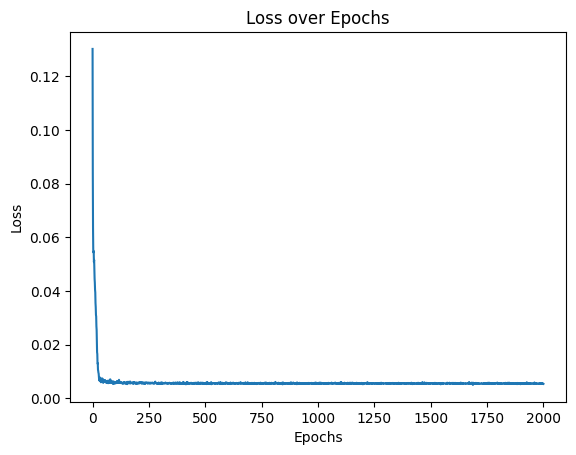

In [36]:
plt.plot(all_losses)
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show();

Модель навчилась, але не факт, що точно)

Щоб краще зрозуміти якість прогнозу, ви можете побудувати графік з кодом нижче (а ще нижче - описано, що відбувається в цьому коді, бо це теж корисно зрозуміти):

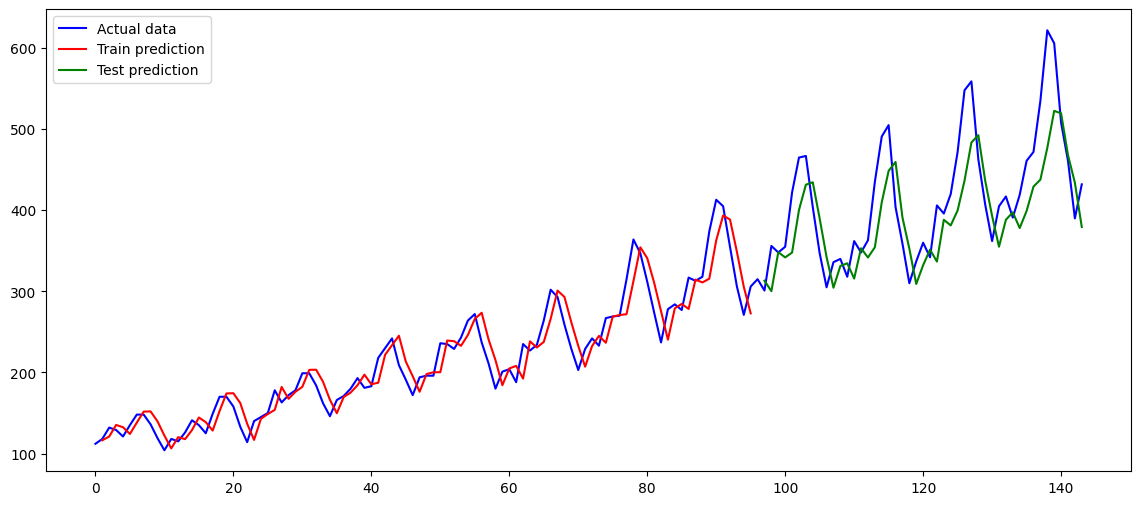

In [37]:
def plot_predicts():
    with torch.no_grad():
        train_size = len(train)

        # predictions in scaled space
        train_pred_scaled = model(X_train)[:, -1].numpy().reshape(-1, 1)
        test_pred_scaled = model(X_test)[:, -1].numpy().reshape(-1, 1)

        # back to original scale (passengers)
        train_pred = scaler.inverse_transform(train_pred_scaled).flatten()
        test_pred = scaler.inverse_transform(test_pred_scaled).flatten()

        train_plot = np.ones_like(num_pessengers) * np.nan
        train_plot[lookback:train_size] = train_pred

        test_plot = np.ones_like(num_pessengers) * np.nan
        test_plot[train_size + lookback:len(num_pessengers)] = test_pred

        plt.figure(figsize=(14, 6))
        plt.plot(num_pessengers, 'b', label='Actual data')
        plt.plot(train_plot, 'r', label='Train prediction')
        plt.plot(test_plot, 'g', label='Test prediction')
        plt.legend()
        plt.show()

plot_predicts()

The model performs well on train data but worst on test data.

**Що відбувається в коді вище.** В цьому коді здійснюється процес прогнозування часових рядів за допомогою LSTM моделі, а також виведення графіку, який показує реальні значення, тренувальні та тестові прогнози. Ось що відбувається на кожному етапі:

1. **`torch.no_grad()`**: Цей контекстний менеджер вимикає обчислення градієнтів, що означає, що під час прогнозування не будуть зберігатися проміжні обчислення для зворотного проходу (backpropagation). Це підвищує ефективність під час прогнозування і зменшує використання пам'яті.

2. **Зсув прогнозів для тренувальних даних:**
   - Створюється масив `train_plot`, який має такий самий розмір, як і часовий ряд (`timeseries`), і заповнюється значеннями NaN (`np.nan`), щоб залишити місце для реальних значень.
   - Модель передбачає виходи для тренувальних даних `X_train`.
   - Використовується лише останнє передбачене значення для кожного входу LSTM (`y_pred[:, -1]`).
   - Прогнози зсуваються, починаючи з індексу `lookback` до кінця тренувальних даних (індекс `train_size`). Цей зсув потрібен, щоб зробити прогноз на основі попередніх даних і відобразити його на правильній частині графіку.

3. **Зсув прогнозів для тестових даних:**
   - Створюється масив `test_plot`, який також заповнюється NaN.
   - Прогнози для тестових даних додаються з індексу `train_size + lookback` до кінця реальних даних, щоб відобразити, де модель починає прогнозувати тестову вибірку.

4. **Побудова графіка:**
   - `plt.plot(timeseries, c='b')`: Виводить реальні значення часового ряду (синя лінія).
   - `plt.plot(train_plot, c='r')`: Виводить тренувальні прогнози (червона лінія).
   - `plt.plot(test_plot, c='g')`: Виводить тестові прогнози (зелена лінія).

**Чому це робиться:**
- Зсув прогнозів для тренувальних і тестових даних дозволяє візуально зрівняти, наскільки добре модель прогнозує як на тренувальній, так і на тестовій вибірках. Зазвичай, червона лінія (тренувальні прогнози) повинна точно відповідати синій лінії (реальні дані), а зелена лінія (тестові прогнози) дає змогу побачити, наскільки модель добре працює на нових даних, яких вона раніше не бачила.

**Завдання 8**. Навчіть модель з hidden_size=100 та порівняйте результати прогнозів з попередніми.

In [38]:
hidden_size = 100
num_layers = 1
model_100 = AirModel(hidden_size, num_layers)

n_epochs = 2000
optimizer = torch.optim.Adam(model_100.parameters(), lr=0.001)
loss_fn = F.mse_loss

In [39]:
all_losses = train_eval(n_epochs, model_100, train_dl, loss_fn, optimizer)

Epoch 0: train RMSE 0.2762, test RMSE 0.8319
Epoch 100: train RMSE 0.0750, test RMSE 0.1582
Epoch 200: train RMSE 0.0744, test RMSE 0.1585
Epoch 300: train RMSE 0.0754, test RMSE 0.1553
Epoch 400: train RMSE 0.0739, test RMSE 0.1574
Epoch 500: train RMSE 0.0741, test RMSE 0.1589
Epoch 600: train RMSE 0.0763, test RMSE 0.1575
Epoch 700: train RMSE 0.0734, test RMSE 0.1742
Epoch 800: train RMSE 0.0748, test RMSE 0.1793
Epoch 900: train RMSE 0.0734, test RMSE 0.1741
Epoch 1000: train RMSE 0.0740, test RMSE 0.1668
Epoch 1100: train RMSE 0.0739, test RMSE 0.1792
Epoch 1200: train RMSE 0.0741, test RMSE 0.1797
Epoch 1300: train RMSE 0.0746, test RMSE 0.1854
Epoch 1400: train RMSE 0.0738, test RMSE 0.1690
Epoch 1500: train RMSE 0.0739, test RMSE 0.1825
Epoch 1600: train RMSE 0.0737, test RMSE 0.1674
Epoch 1700: train RMSE 0.0743, test RMSE 0.1624
Epoch 1800: train RMSE 0.0751, test RMSE 0.1634
Epoch 1900: train RMSE 0.0737, test RMSE 0.1767
Epoch 2000: train RMSE 0.0736, test RMSE 0.1694


The model with `hidden_size=100` performs better: test RMSE `0.1694` compared to test RMSE `0.1713`

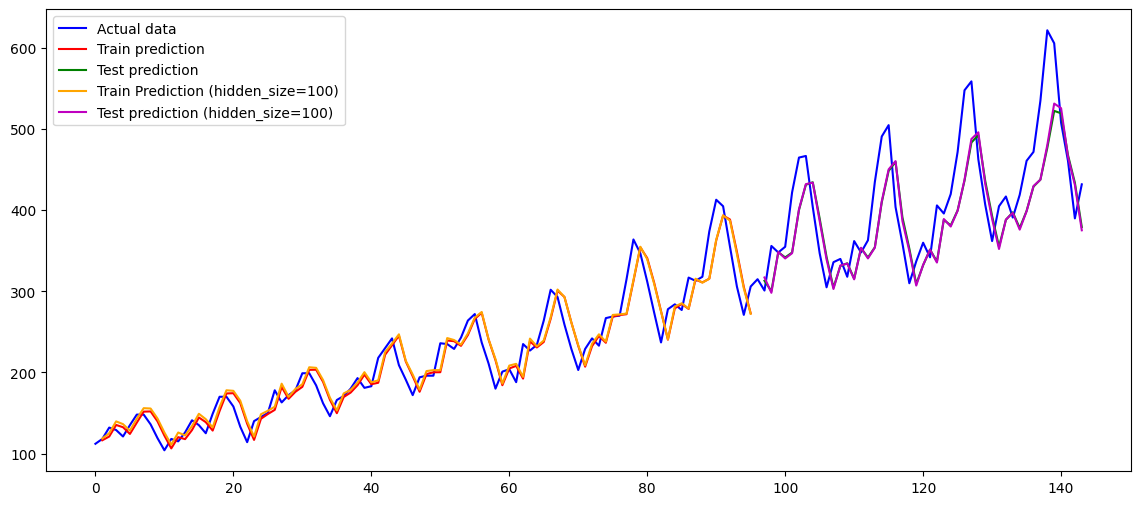

In [40]:
def plot_predicts():
    with torch.no_grad():
        train_size = len(train)

        # predictions in scaled space
        train_pred_scaled = model(X_train)[:, -1].numpy().reshape(-1, 1)
        test_pred_scaled = model(X_test)[:, -1].numpy().reshape(-1, 1)
        train_pred_scaled_100 = model_100(X_train)[:, -1].numpy().reshape(-1, 1)
        test_pred_scaled_100 = model_100(X_test)[:, -1].numpy().reshape(-1, 1)

        # back to original scale (passengers)
        train_pred = scaler.inverse_transform(train_pred_scaled).flatten()
        test_pred = scaler.inverse_transform(test_pred_scaled).flatten()
        train_pred_100 = scaler.inverse_transform(train_pred_scaled_100).flatten()
        test_pred_100 = scaler.inverse_transform(test_pred_scaled_100).flatten()

        train_plot = np.ones_like(num_pessengers) * np.nan
        train_plot[lookback:train_size] = train_pred

        test_plot = np.ones_like(num_pessengers) * np.nan
        test_plot[train_size + lookback:len(num_pessengers)] = test_pred

        train_100_plot = np.ones_like(num_pessengers) * np.nan
        train_100_plot[lookback:train_size] = train_pred_100

        test_100_plot = np.ones_like(num_pessengers) * np.nan
        test_100_plot[train_size+lookback:len(num_pessengers)] = test_pred_100

        plt.figure(figsize=(14, 6))
        plt.plot(num_pessengers, 'b', label='Actual data')
        plt.plot(train_plot, 'r', label='Train prediction')
        plt.plot(test_plot, 'g', label='Test prediction')
        plt.plot(train_100_plot, 'orange', label='Train Prediction (hidden_size=100)')
        plt.plot(test_100_plot, 'm', label='Test prediction (hidden_size=100)')
        plt.legend()
        plt.show()

plot_predicts()

The plot shows the difference between predictions from 2 models, and we can see that the model with `hidden_size=100` performs better.